# EDA: Fraudes com Cartões de Crédito

análise de **10 mil dados** artificiais de usos de cartões de crédito.

Dataset: [Kaggle](https://www.kaggle.com/datasets/miadul/credit-card-fraud-detection-dataset)

## Objetivos:
- Identificar quais variáveis mais discriminam fraudes de transações legítimas
- Fundamentar próximos passos para tornar a detecção mais previsível

## Sumário
- [1. Carregamento e limpeza](#limpeza)
- [2. KPIs](#kpis)
- [3. Análise de Horário](#temporal)
- [4. Análise de Valor](#valor)

In [2]:
# Importações
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 300)
pd.set_option('display.max_colwidth', 50)

<div id="limpeza"></div>

## 1. Carregamento e limpeza

In [4]:
df = pd.read_csv('credit_card_fraud_10k.csv')

# Quantidade de linhas
print(f"Linhas: {len(df):,} | Colunas: {len(df.columns)}")

# Datatypes
print(df.dtypes)

df.head(5)

Linhas: 10,000 | Colunas: 10
transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category          str
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


### O que podemos extrair dessa base de dados?

1 - Quais horas possuem mais chances de serem fraudes

2 - Correlação do valor da transição com fraude

3 - Quais tipos de mercadorias possuem mais chances de serem fraudes

4 - Se fraudes estrangeiras possuem mais chances de serem fraudes

<div id="kpis"></div>

## 2. Kpis

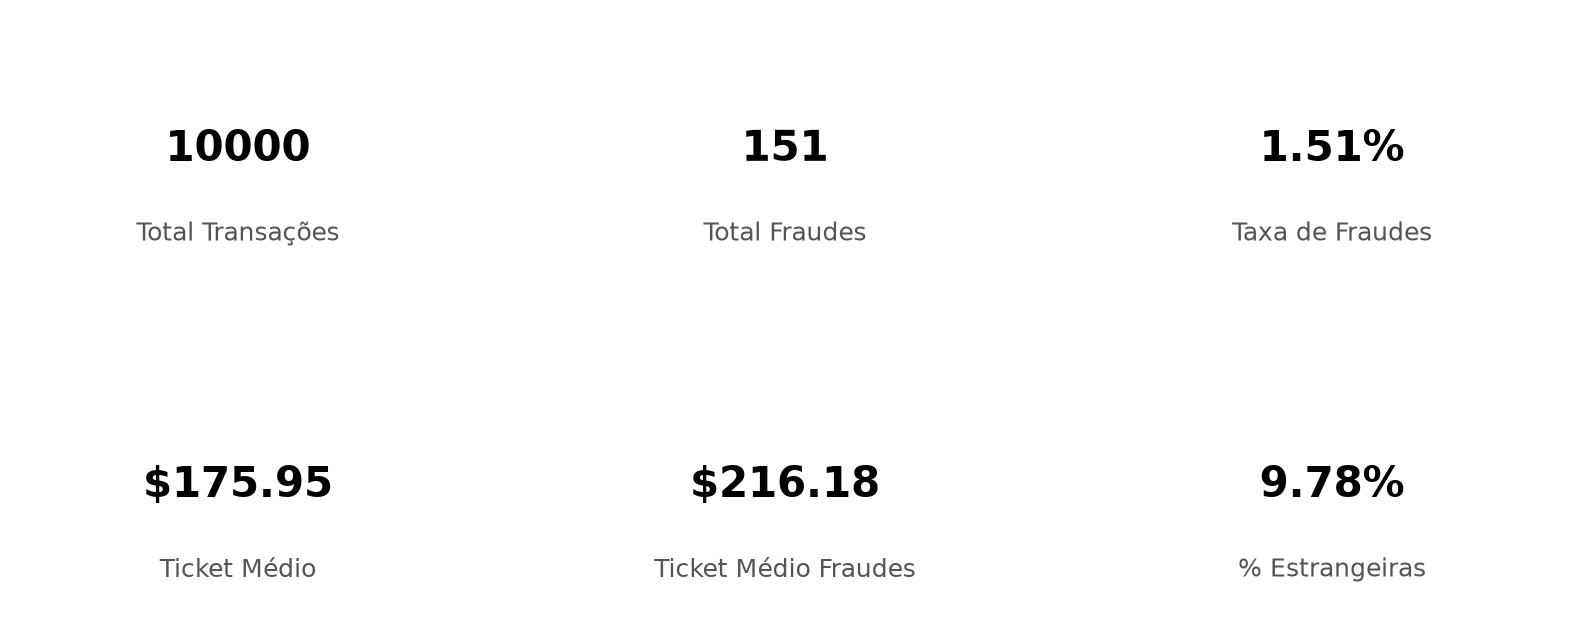

In [42]:
total_transacoes = df['transaction_id'].shape[0]
total_fraudes = df['is_fraud'].sum()
total_trans_estrangeiras = df[df['foreign_transaction'] == 1].shape[0]
ticket_medio = df['amount'].sum() / df['amount'].shape[0]
ticket_medio_fraudes = df[df['is_fraud'] == 1]['amount'].mean()


fig, axes = plt.subplots(2, 3, figsize=(20,8))
axes = axes.flatten()

kpis = [
    (f'{total_transacoes}', 'Total Transações'),
    (f'{total_fraudes}', 'Total Fraudes'),
    (f'{total_fraudes/df['is_fraud'].shape[0] * 100}%', 'Taxa de Fraudes'),
    (f'${ticket_medio:.2f}', 'Ticket Médio'),
    (f'${ticket_medio_fraudes:.2f}', 'Ticket Médio Fraudes'),
    (f'{total_trans_estrangeiras / df['foreign_transaction'].shape[0] * 100}%', '% Estrangeiras')
]

for ax, (valor, titulo) in zip(axes, kpis):
    ax.text(0.5, 0.5, valor, fontsize=30, fontweight='bold', ha='center', va='center')
    ax.text(0.5, 0.2, titulo, fontsize=18, ha='center', va='center', color='#555555')
    ax.set_axis_off()
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['top'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)
    ax.set_facecolor('#FAFAFA')



<div id="temporal"></div>

## 3. Análise de Horário

In [43]:
horario = df.groupby('transaction_hour').agg(
    total=('transaction_id', 'count'),
    fraudes=('is_fraud', 'sum'),
).assign(taxa_fraude=lambda x: x['fraudes'] / x['total'] * 100)

print(horario)

                  total  fraudes  taxa_fraude
transaction_hour                             
0                   417       37     8.872902
1                   425       34     8.000000
2                   385       23     5.974026
3                   425       27     6.352941
4                   384        1     0.260417
5                   419        2     0.477327
6                   413        2     0.484262
7                   425        0     0.000000
8                   424        3     0.707547
9                   426        1     0.234742
10                  358        1     0.279330
11                  385        2     0.519481
12                  417        0     0.000000
13                  420        2     0.476190
14                  458        1     0.218341
15                  432        2     0.462963
16                  421        0     0.000000
17                  429        2     0.466200
18                  439        1     0.227790
19                  421        4  

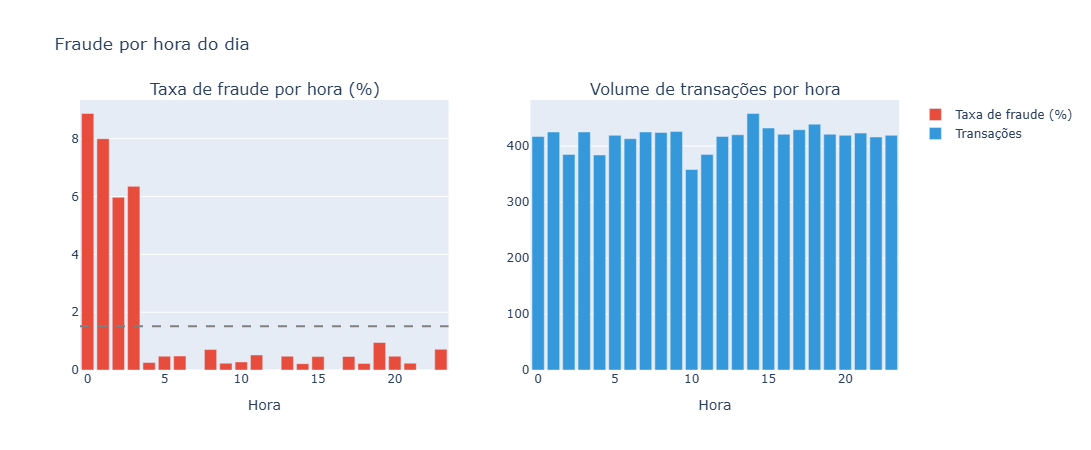

In [46]:
taxa_media = df['is_fraud'].mean() * 100

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Taxa de fraude por hora (%)", "Volume de transações por hora"),
    vertical_spacing=0.15,
)

fig.add_trace(
    go.Bar(
        x=horario.index,
        y=horario['taxa_fraude'],
        name="Taxa de fraude (%)",
        marker_color="#e74c3c",
    ),
    row=1, col=1,
)

fig.add_hline(y=taxa_media, line_dash="dash", line_color="gray", row=1, col=1)

fig.add_trace(
    go.Bar(
        x=horario.index,
        y=horario['total'],
        name="Transações",
        marker_color='#3498db',
    ),
    row=1, col=2,
)

fig.update_layout(height=450, title_text="Fraude por hora do dia")
fig.update_xaxes(title_text="Hora", row=1, col=1)
fig.update_xaxes(title_text="Hora", row=1, col=2)

fig.show()

<div id="valor"></div>

## 4. Análise de valor

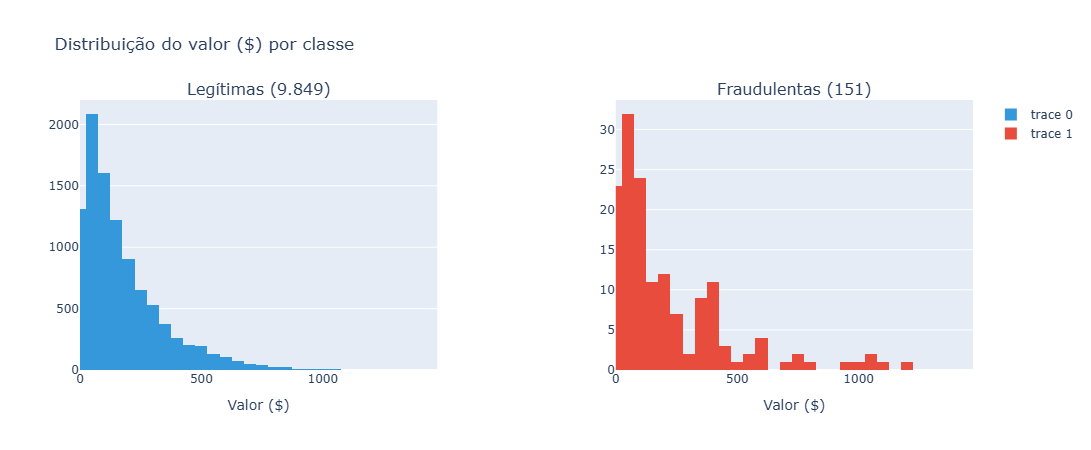

In [48]:
valor = df.groupby('is_fraud')['amount'].agg(
    n='count',
    media='mean',
    mediana='median',
    p95=lambda x: x.quantile(0.95),
    total='sum',
)
valor.round(2)

lim = df['amount'].max()

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Legítimas (9.849)", "Fraudulentas (151)"),
    horizontal_spacing=0.2,
)

fig.add_trace(
    go.Histogram(x=df.loc[df['is_fraud'] == 0, 'amount'], marker_color="#3498db", nbinsx=40),
    row=1, col=1,
)
fig.add_trace(
    go.Histogram(x=df.loc[df['is_fraud'] == 1, 'amount'], marker_color="#e74c3c", nbinsx=40),
    row=1, col=2,
)

fig.update_layout(height=450, title_text="Distribuição do valor ($) por classe")
fig.update_xaxes(title_text="Valor ($)", range=[0, lim], row=1, col=1)
fig.update_xaxes(title_text="Valor ($)", range=[0, lim], row=1, col=2)

fig.show()